In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/HandInfo.csv
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009564.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008693.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0008334.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0006432.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0000951.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0007308.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0003491.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0010098.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0001966.jpg
/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset/Hands/Hands/Hand_0009925.jpg
/kaggle/input/d

In [2]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

plt.style.use("ggplot")

In [3]:
#Dataset Loading
dataset_path="/kaggle/input/datasets/shyambhu/hands-and-palm-images-dataset"

csv_path=dataset_path+"/HandInfo.csv"

image_path=dataset_path+"/Hands/Hands"

df=pd.read_csv(csv_path)

df.head()

,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
0,0,27,male,fair,0,0,dorsal right,Hand_0000002.jpg,0
1,0,27,male,fair,0,0,dorsal right,Hand_0000003.jpg,0
2,0,27,male,fair,0,0,dorsal right,Hand_0000004.jpg,0
3,0,27,male,fair,0,0,dorsal right,Hand_0000005.jpg,0
4,0,27,male,fair,0,0,dorsal right,Hand_0000006.jpg,0


In [4]:
#Dataset Information
print("Shape:",df.shape)

df.info()

df.describe(include="all")

Shape: (11076, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11076 entries, 0 to 11075
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              11076 non-null  int64 
 1   age             11076 non-null  int64 
 2   gender          11076 non-null  object
 3   skinColor       11076 non-null  object
 4   accessories     11076 non-null  int64 
 5   nailPolish      11076 non-null  int64 
 6   aspectOfHand    11076 non-null  object
 7   imageName       11076 non-null  object
 8   irregularities  11076 non-null  int64 
dtypes: int64(5), object(4)
memory usage: 778.9+ KB


,id,age,gender,skinColor,accessories,nailPolish,aspectOfHand,imageName,irregularities
count,1.107600e+04,11076.000000,11076,11076,11076.000000,11076.000000,11076,11076,11076.000000
unique,NaN,NaN,2,4,NaN,NaN,4,11076,NaN
top,NaN,NaN,female,medium,NaN,NaN,dorsal right,Hand_0011744.jpg,NaN
freq,NaN,NaN,7109,6495,NaN,NaN,2892,1,NaN
mean,2.031043e+05,22.494583,NaN,NaN,0.289906,0.096334,NaN,NaN,0.014807
std,1.086731e+06,6.918974,NaN,NaN,0.453739,0.295063,NaN,NaN,0.120784
min,0.000000e+00,18.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
25%,5.760000e+02,21.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
50%,1.050000e+03,21.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000
75%,1.539250e+03,22.000000,NaN,NaN,1.000000,0.000000,NaN,NaN,0.000000


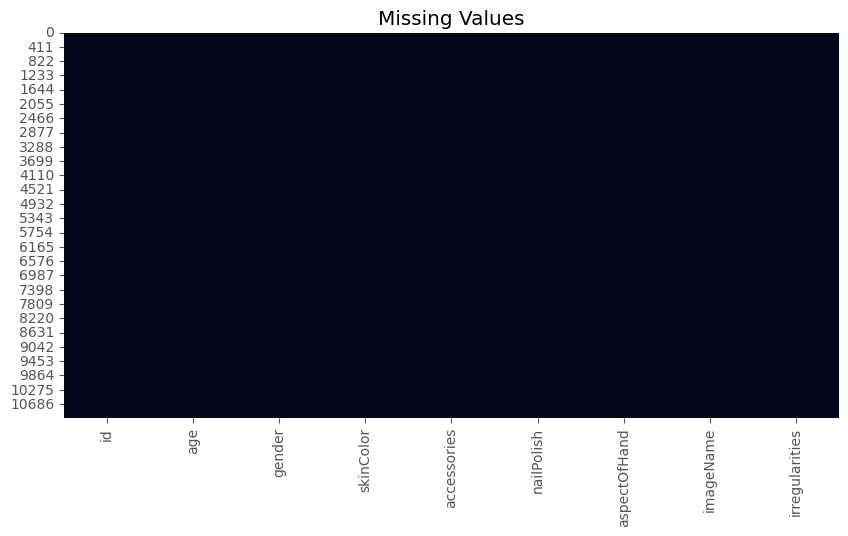

In [5]:
#Missing Values
df.isnull().sum()
plt.figure(figsize=(10,5))

sns.heatmap(df.isnull(),cbar=False)

plt.title("Missing Values")

plt.show()

In [6]:
#Duplicate Records
print(df.duplicated().sum())

0


In [7]:
#Explore Metadata
print(df.columns)

Index(['id', 'age', 'gender', 'skinColor', 'accessories', 'nailPolish',
       'aspectOfHand', 'imageName', 'irregularities'],
      dtype='object')


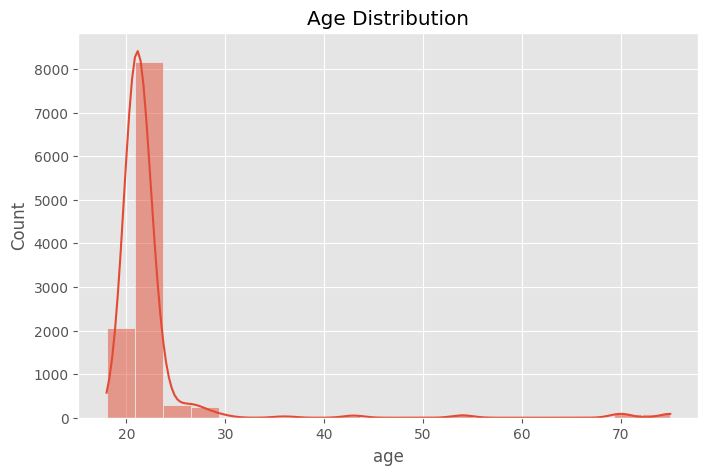

In [8]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df.age,bins=20,kde=True)

plt.title("Age Distribution")

plt.show()

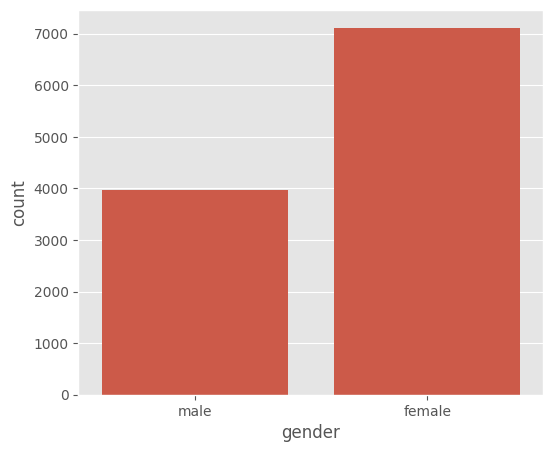

In [9]:
#Gender Distribution
plt.figure(figsize=(6,5))

sns.countplot(data=df,x="gender")

plt.show()

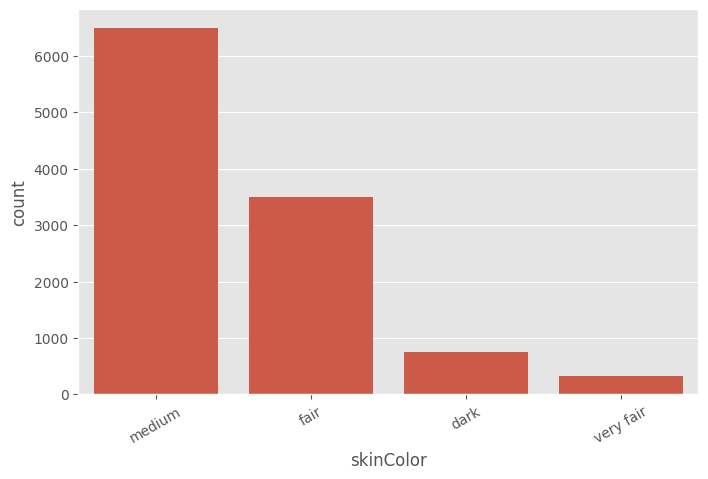

In [10]:
#Skin Color Distribution
plt.figure(figsize=(8,5))

sns.countplot(
data=df,
x="skinColor",
order=df.skinColor.value_counts().index)

plt.xticks(rotation=30)

plt.show()

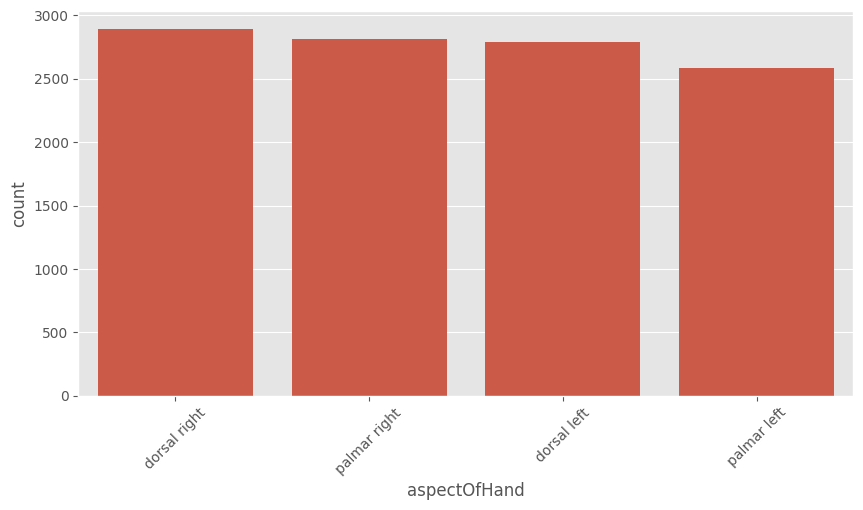

In [11]:
#Aspect of Hand
plt.figure(figsize=(10,5))

sns.countplot(
data=df,
x="aspectOfHand",
order=df.aspectOfHand.value_counts().index)

plt.xticks(rotation=45)

plt.show()

<Axes: xlabel='accessories', ylabel='count'>

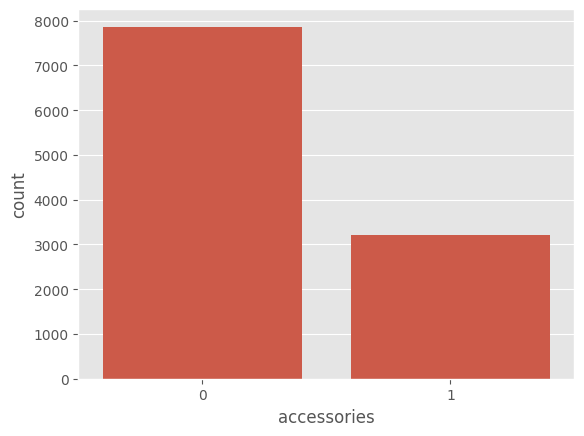

In [12]:
#Accessories
sns.countplot(data=df,x="accessories")

<Axes: xlabel='nailPolish', ylabel='count'>

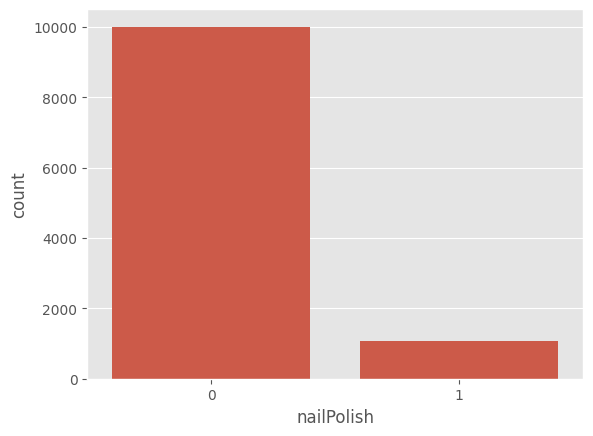

In [13]:
#Nail Polish
sns.countplot(data=df,x="nailPolish")

<Axes: xlabel='irregularities', ylabel='count'>

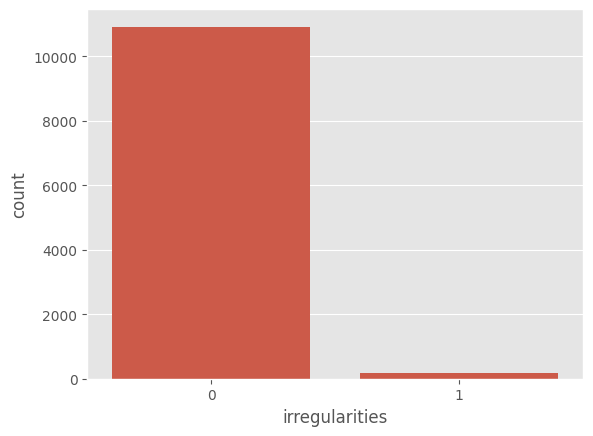

In [14]:
#Irregularities
sns.countplot(data=df,x="irregularities")

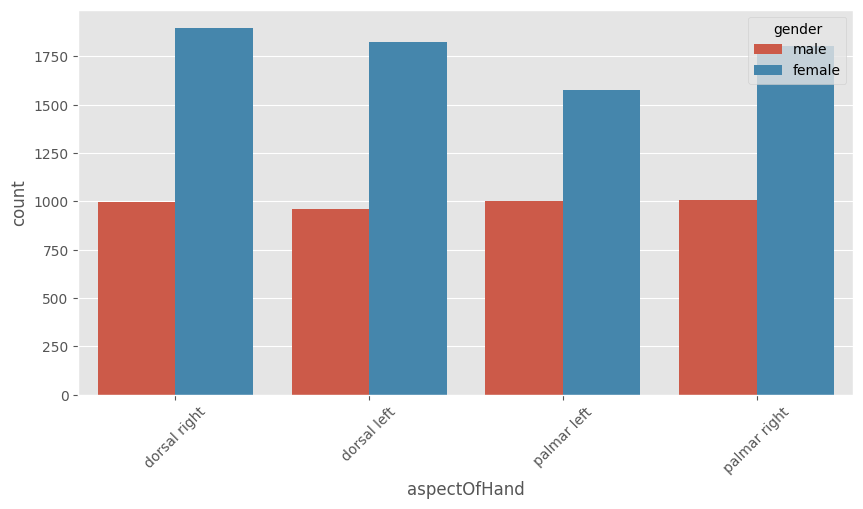

In [15]:
#Gender vs Hand Aspect
plt.figure(figsize=(10,5))

sns.countplot(
data=df,
x="aspectOfHand",
hue="gender")

plt.xticks(rotation=45)

plt.show()

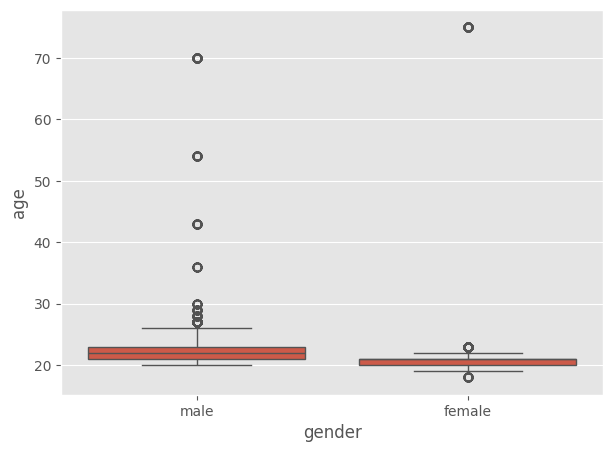

In [16]:
#Age vs Gender
plt.figure(figsize=(7,5))

sns.boxplot(
data=df,
x="gender",
y="age")

plt.show()

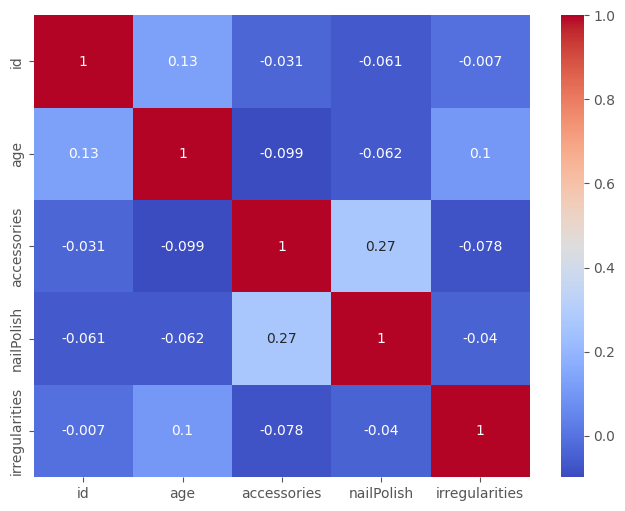

In [17]:
#Correlation
numeric=df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
numeric.corr(),
annot=True,
cmap="coolwarm")

plt.show()

In [18]:
#Image EDA
image_paths=[]

for root,dirs,files in os.walk(image_path):

    for file in files:

        if file.endswith((".jpg",".png",".jpeg")):

            image_paths.append(os.path.join(root,file))

print(len(image_paths))

11076


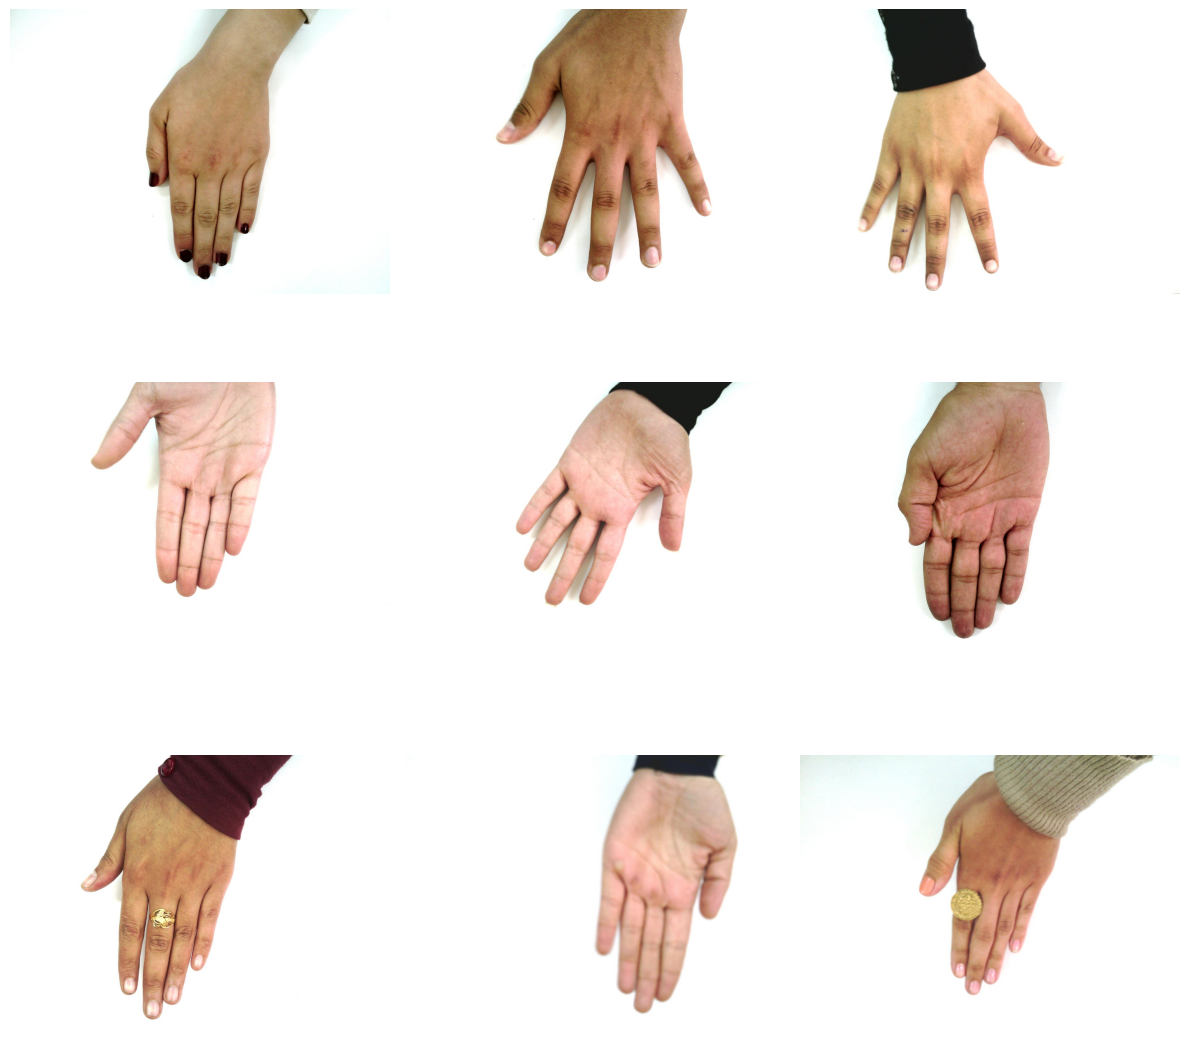

In [19]:
#Show Random Images
plt.figure(figsize=(12,12))

sample=random.sample(image_paths,9)

for i,path in enumerate(sample):

    img=Image.open(path)

    plt.subplot(3,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.tight_layout()

plt.show()

In [20]:
#Image Resolution
width=[]
height=[]

for path in image_paths:

    img=Image.open(path)

    width.append(img.size[0])

    height.append(img.size[1])

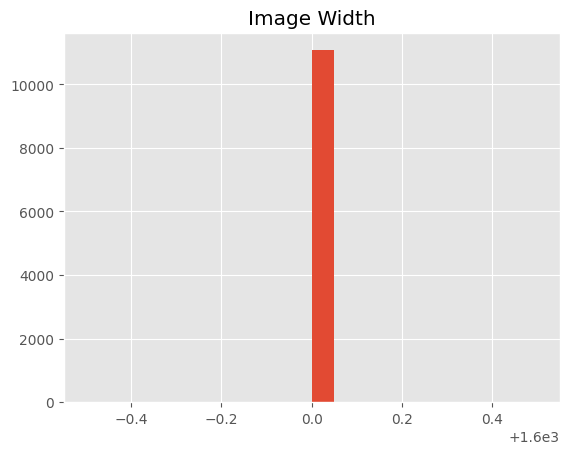

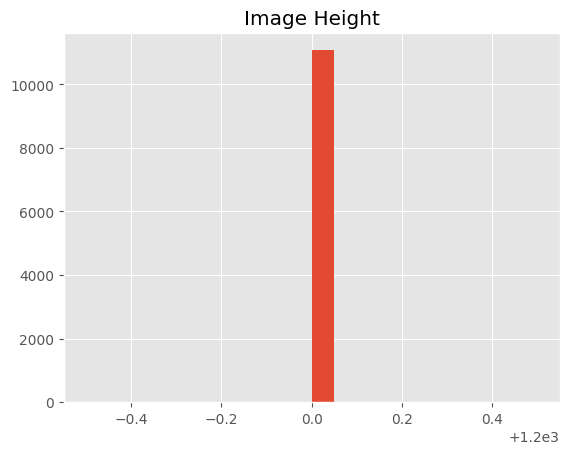

In [21]:
#Histogram
plt.hist(width,bins=20)

plt.title("Image Width")

plt.show()

#//
plt.hist(height,bins=20)

plt.title("Image Height")

plt.show()

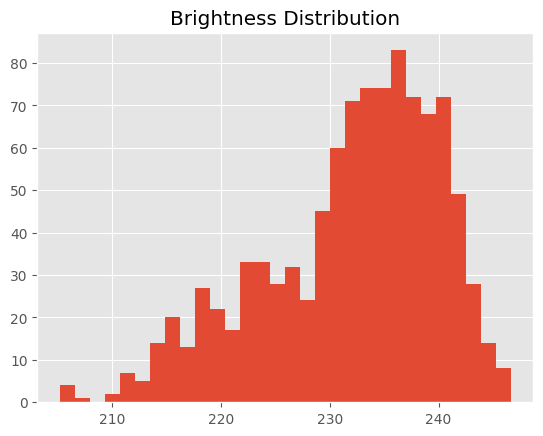

In [22]:
#Brightness
brightness=[]

for path in image_paths[:1000]:

    img=cv2.imread(path,0)

    brightness.append(img.mean())

plt.hist(brightness,bins=30)

plt.title("Brightness Distribution")

plt.show()

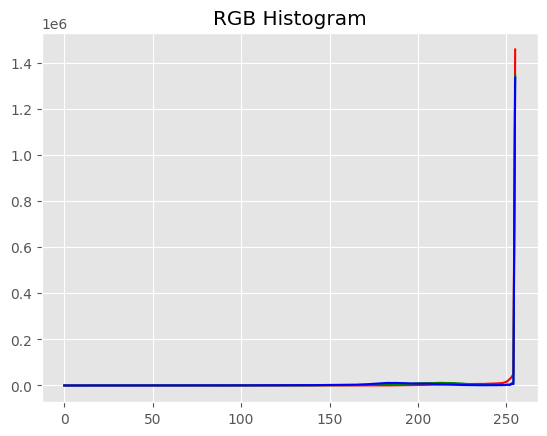

In [23]:
#RGB Histogram
img=cv2.imread(random.choice(image_paths))

img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

colors=("r","g","b")

for i,c in enumerate(colors):

    hist=cv2.calcHist([img],[i],None,[256],[0,256])

    plt.plot(hist,color=c)

plt.title("RGB Histogram")

plt.show()

In [24]:
#Image Size Summary
sizes=[]

for path in image_paths:

    img=Image.open(path)

    sizes.append(img.size)

size_df=pd.DataFrame(
sizes,
columns=["Width","Height"])

size_df.describe()

,Width,Height
count,11076.0,11076.0
mean,1600.0,1200.0
std,0.0,0.0
min,1600.0,1200.0
25%,1600.0,1200.0
50%,1600.0,1200.0
75%,1600.0,1200.0
max,1600.0,1200.0


In [25]:
#Corrupt Images
corrupt=[]

for path in image_paths:

    if cv2.imread(path) is None:

        corrupt.append(path)

print("Corrupt Images:",len(corrupt))

Corrupt Images: 0
